## mlflow_task Hand in 9.

In this exercise, do the following:
1. Load the dataset used in the time series example - Energy consumption data. You can find it in the notebook "TSA_Example" in Time Series folder in Moodle.
2. Setup a nested MLFlow loop where different modelling experiments can be tracked and the use the dataset in point 1 to experiment and track models. You should do following combinations:
    1. At least 3 model types
    2. At least 3 different feature combinations
    3. At least 3 different options for 3 different hyperparameters
    4. At least 3 different time splits for train test
3. For each option in the combination, you should calculate & log the following in MLFlow:
    1. RMSE
    2. MAE
    3. Plot of actual vs predicted for 1 month data
    4. Plot of actual vs predicted for 1 week of data
    5. All of the combination info in point 2, such as which model, what feature combindation, what hyperparameter, what train test split has been used
4. Turn on MLFlow UI and track your experiments

In [2]:
import os
import kagglehub

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import mlflow
import mlflow.sklearn
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
import subprocess
import time
import IPython.display as display
import tempfile
from sklearn.metrics import mean_squared_error, mean_absolute_error, root_mean_squared_error

In [3]:
path = kagglehub.dataset_download("robikscube/hourly-energy-consumption")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\Bruger\.cache\kagglehub\datasets\robikscube\hourly-energy-consumption\versions\3


In [4]:
dataset_path = r"C:\Users\Bruger\.cache\kagglehub\datasets\robikscube\hourly-energy-consumption\versions\3"

files = os.listdir(dataset_path)
print(files)


['AEP_hourly.csv', 'COMED_hourly.csv', 'DAYTON_hourly.csv', 'DEOK_hourly.csv', 'DOM_hourly.csv', 'DUQ_hourly.csv', 'EKPC_hourly.csv', 'est_hourly.paruqet', 'FE_hourly.csv', 'NI_hourly.csv', 'PJME_hourly.csv', 'PJMW_hourly.csv', 'pjm_hourly_est.csv', 'PJM_Load_hourly.csv']


In [5]:
file_path = r"C:\Users\Bruger\.cache\kagglehub\datasets\robikscube\hourly-energy-consumption\versions\3\PJME_hourly.csv"

**Load the data and sort it by index**

In [54]:
df = pd.read_csv(file_path)
df = df.set_index('Datetime')
df.index = pd.to_datetime(df.index)
df = df.sort_index()
df

,PJME_MW
Datetime,
2002-01-01 01:00:00,30393.0
2002-01-01 02:00:00,29265.0
2002-01-01 03:00:00,28357.0
2002-01-01 04:00:00,27899.0
2002-01-01 05:00:00,28057.0
...,...
2018-08-02 20:00:00,44057.0
2018-08-02 21:00:00,43256.0
2018-08-02 22:00:00,41552.0


## Using a smaller dataset
**because the dataset is so large we are going to reduce it down, this will result in some of the features later on not being so impactful.**

In [8]:
df_s = pd.DataFrame(df.loc["2018-01"])
df_s.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 744 entries, 2018-01-01 00:00:00 to 2018-01-31 23:00:00
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   PJME_MW  744 non-null    float64
dtypes: float64(1)
memory usage: 11.6 KB


**Create features for training the model**

In [9]:
df = df.copy()

# Basic time-based features
df['hour'] = df.index.hour
df['dayofweek'] = df.index.dayofweek
df['quarter'] = df.index.quarter
df['month'] = df.index.month
df['year'] = df.index.year
df['dayofyear'] = df.index.dayofyear
df['dayofmonth'] = df.index.day
df['weekofyear'] = df.index.isocalendar().week

# Basic time-based features
df_s['hour'] = df_s.index.hour
df_s['dayofweek'] = df_s.index.dayofweek
df_s['quarter'] = df_s.index.quarter
df_s['month'] = df_s.index.month
df_s['year'] = df_s.index.year
df_s['dayofyear'] = df_s.index.dayofyear
df_s['dayofmonth'] = df_s.index.day
df_s['weekofyear'] = df_s.index.isocalendar().week


**Creating the label for the training**

In [10]:
y = df_s["PJME_MW"]
df = df_s.drop("PJME_MW",axis=1)
df_s

,PJME_MW,hour,dayofweek,quarter,month,year,dayofyear,dayofmonth,weekofyear
Datetime,,,,,,,,,
2018-01-01 00:00:00,39928.0,0,0,1,1,2018,1,1,1
2018-01-01 01:00:00,38925.0,1,0,1,1,2018,1,1,1
2018-01-01 02:00:00,38298.0,2,0,1,1,2018,1,1,1
2018-01-01 03:00:00,37808.0,3,0,1,1,2018,1,1,1
2018-01-01 04:00:00,37742.0,4,0,1,1,2018,1,1,1
...,...,...,...,...,...,...,...,...,...
2018-01-31 19:00:00,40510.0,19,2,1,1,2018,31,31,5
2018-01-31 20:00:00,40054.0,20,2,1,1,2018,31,31,5
2018-01-31 21:00:00,39104.0,21,2,1,1,2018,31,31,5


In [11]:
df_s.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 744 entries, 2018-01-01 00:00:00 to 2018-01-31 23:00:00
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   PJME_MW     744 non-null    float64
 1   hour        744 non-null    int32  
 2   dayofweek   744 non-null    int32  
 3   quarter     744 non-null    int32  
 4   month       744 non-null    int32  
 5   year        744 non-null    int32  
 6   dayofyear   744 non-null    int32  
 7   dayofmonth  744 non-null    int32  
 8   weekofyear  744 non-null    UInt32 
dtypes: UInt32(1), float64(1), int32(7)
memory usage: 35.6 KB


In [12]:
df_s

,PJME_MW,hour,dayofweek,quarter,month,year,dayofyear,dayofmonth,weekofyear
Datetime,,,,,,,,,
2018-01-01 00:00:00,39928.0,0,0,1,1,2018,1,1,1
2018-01-01 01:00:00,38925.0,1,0,1,1,2018,1,1,1
2018-01-01 02:00:00,38298.0,2,0,1,1,2018,1,1,1
2018-01-01 03:00:00,37808.0,3,0,1,1,2018,1,1,1
2018-01-01 04:00:00,37742.0,4,0,1,1,2018,1,1,1
...,...,...,...,...,...,...,...,...,...
2018-01-31 19:00:00,40510.0,19,2,1,1,2018,31,31,5
2018-01-31 20:00:00,40054.0,20,2,1,1,2018,31,31,5
2018-01-31 21:00:00,39104.0,21,2,1,1,2018,31,31,5


**Select feature combinations**

In [13]:
feature_combinations = [df_s[["hour","quarter"]],
                        df_s[["month","year"]],
                        df_s
                       ]

**Select test data sizes**

In [14]:
t_sizes = [0.2,0.25,0.3]

**Hyperparameter combinations**

In [15]:
hyperparams = [[100,250,500],[3,6,9],[3,6,9]]

(744, 2) (744,)


2025/03/15 20:35:21 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


(744, 2) (744,)


2025/03/15 20:35:25 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


(744, 2) (744,)


...

(744, 9) (744,)


2025/03/15 20:39:01 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


(744, 9) (744,)


2025/03/15 20:39:05 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.



Summary of Experiment Results:
                                             features                   model  \
0                        hour  quarter
Datetime   ...            RandomForest   
1                        hour  quarter
Datetime   ...  DecisionTreeClassifier   
2                        hour  quarter
Datetime   ...       KNearestNeighbors   
3                        hour  quarter
Datetime   ...            RandomForest   
4                        hour  quarter
Datetime   ...  DecisionTreeClassifier   
5                        hour  quarter
Datetime   ...       KNearestNeighbors   
6                        hour  quarter
Datetime   ...            RandomForest   
7                        hour  quarter
Datetime   ...  DecisionTreeClassifier   
8                        hour  quarter
Datetime   ...       KNearestNeighbors   
9                        hour  quarter
Datetime   ...            RandomForest   
10                       hour  quarter
Datetime   ...  DecisionTreeClassifier

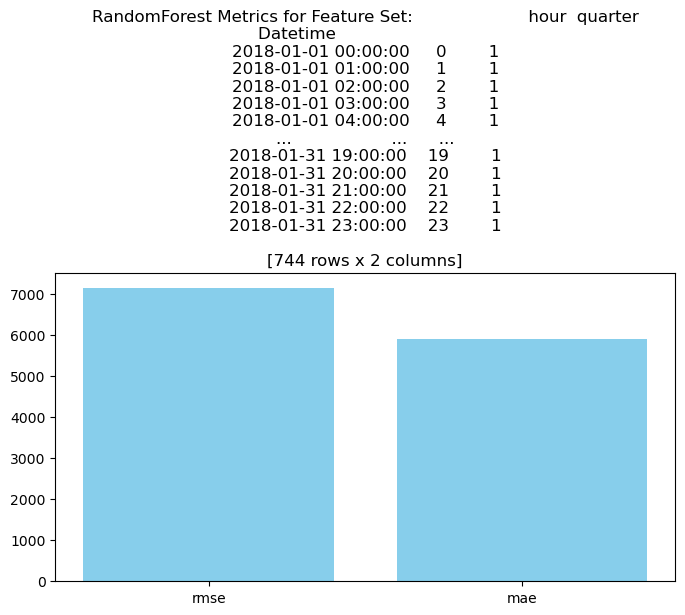

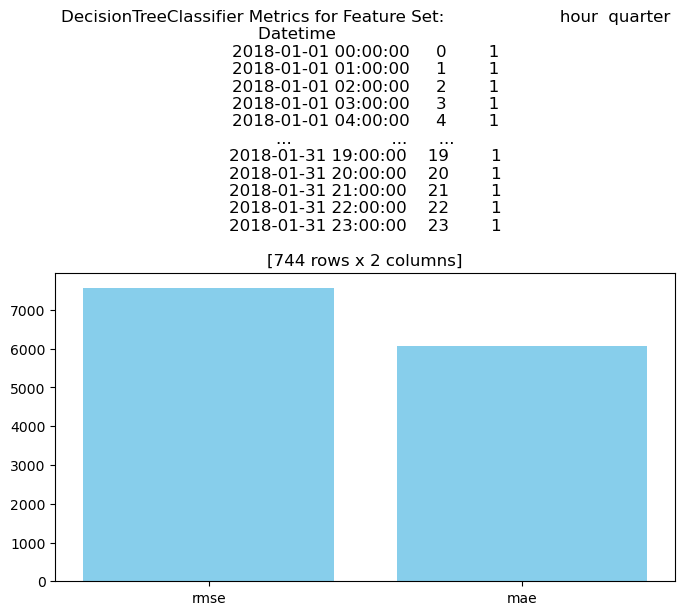

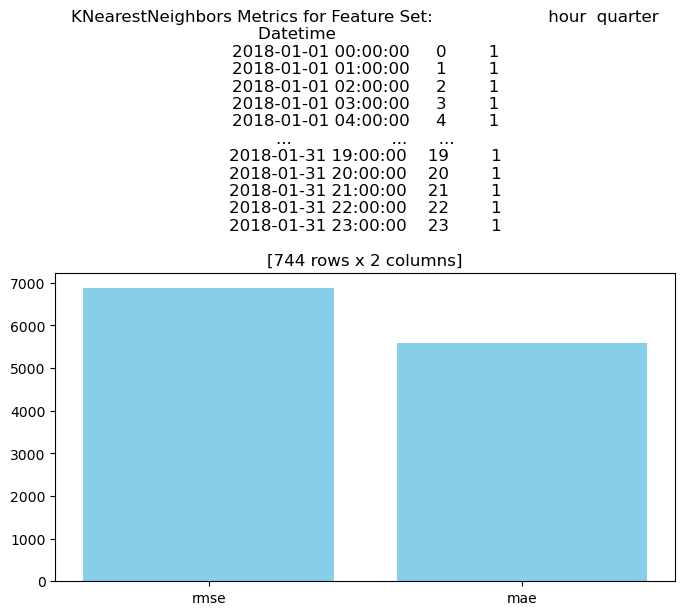

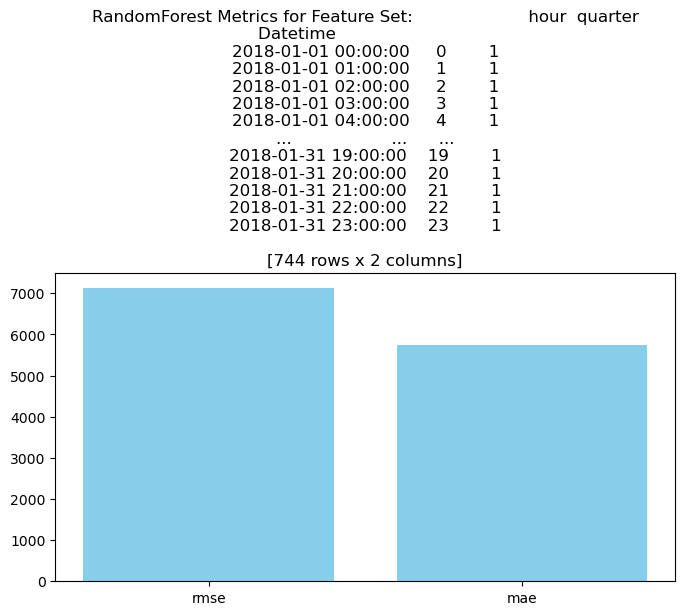

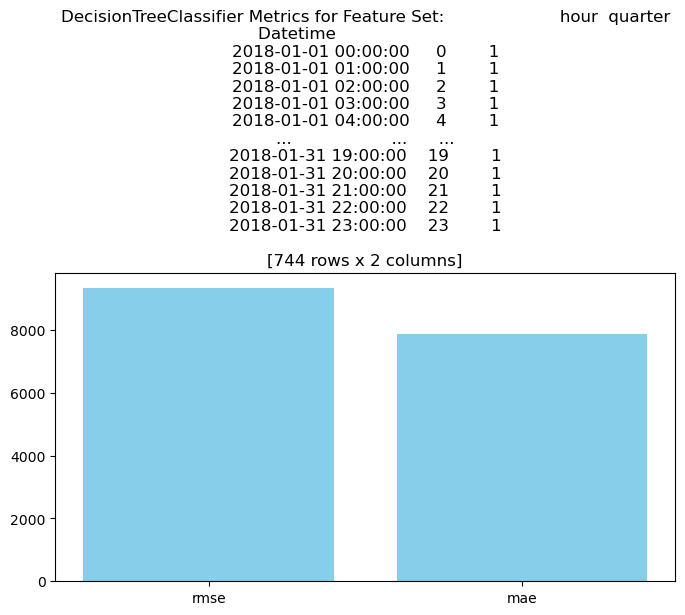

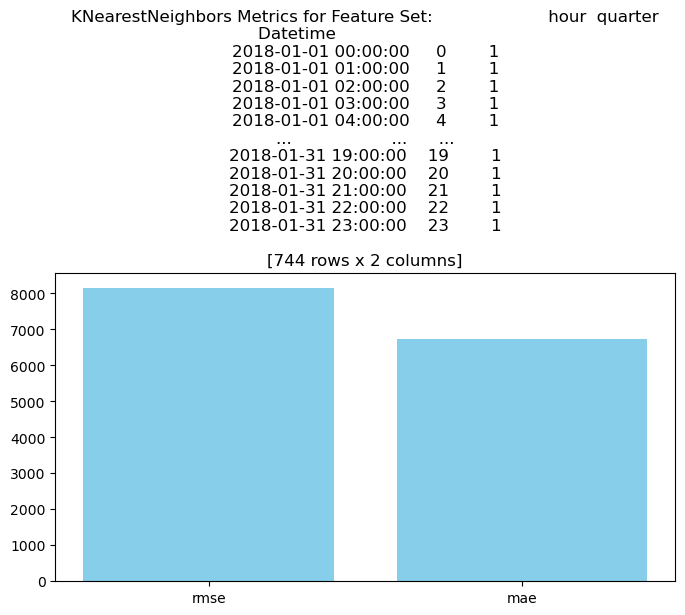

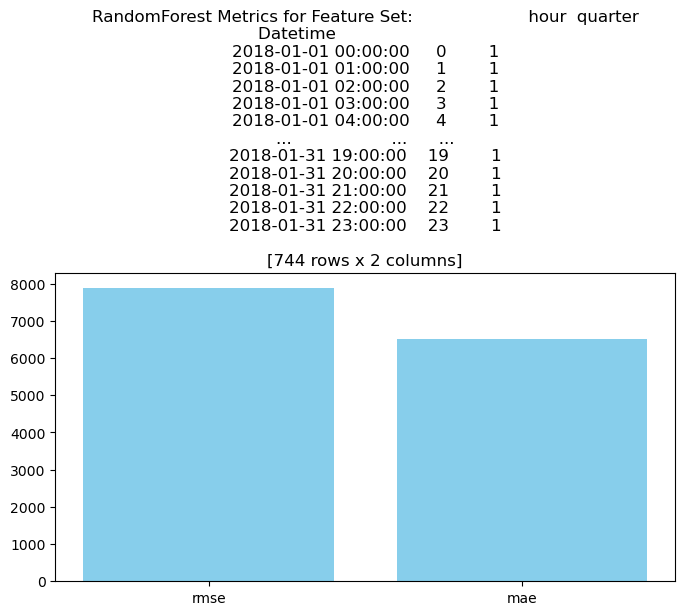

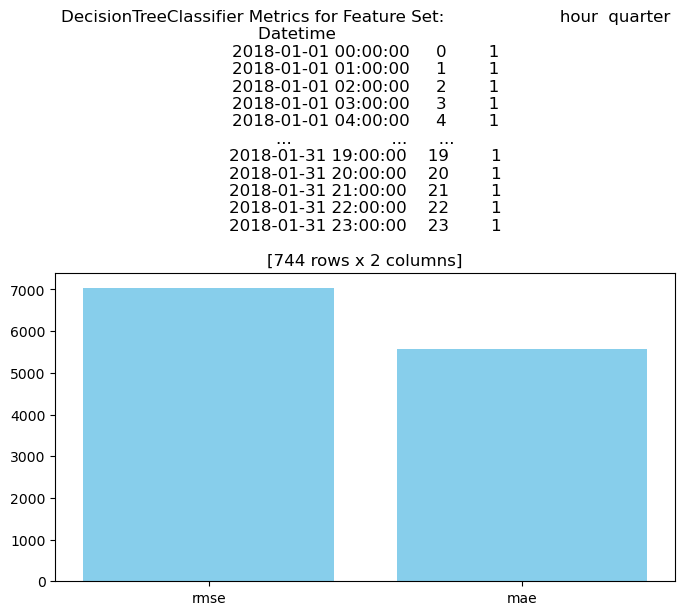

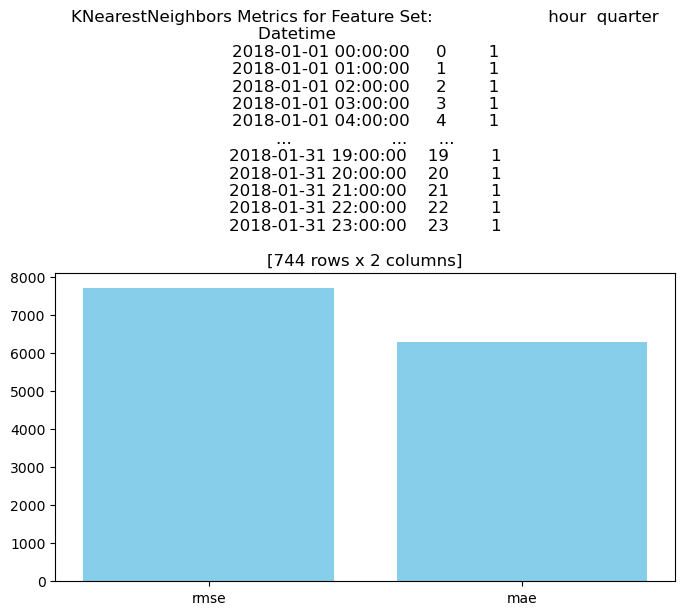

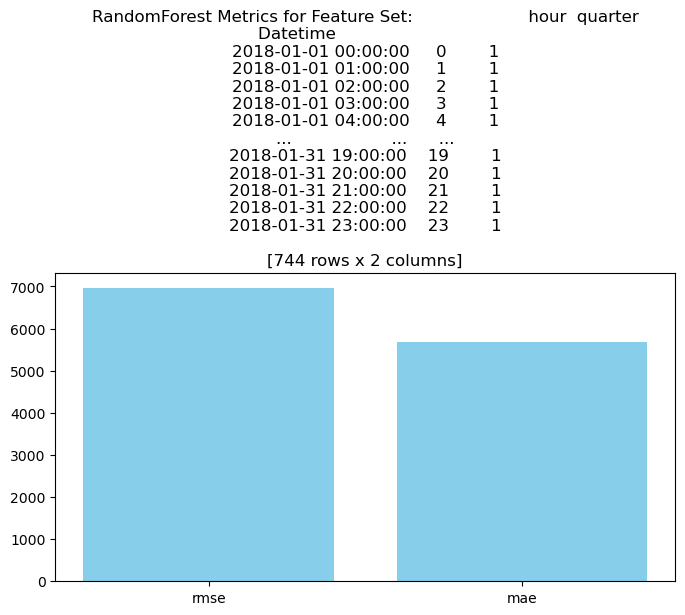

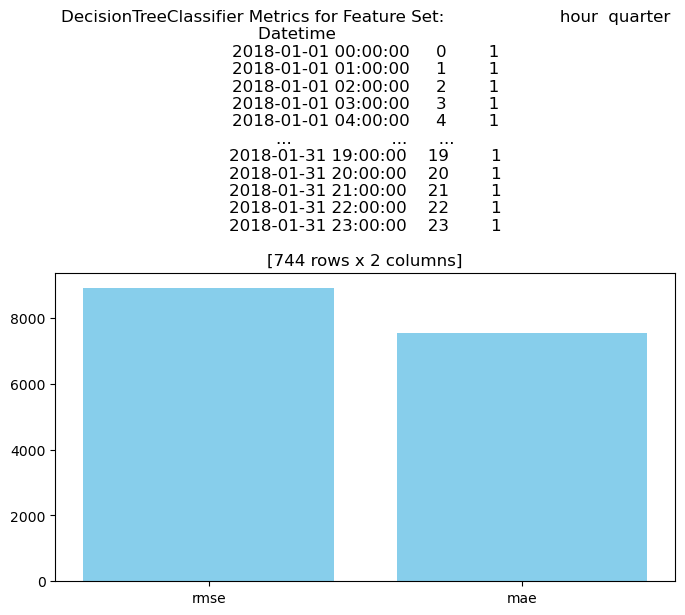

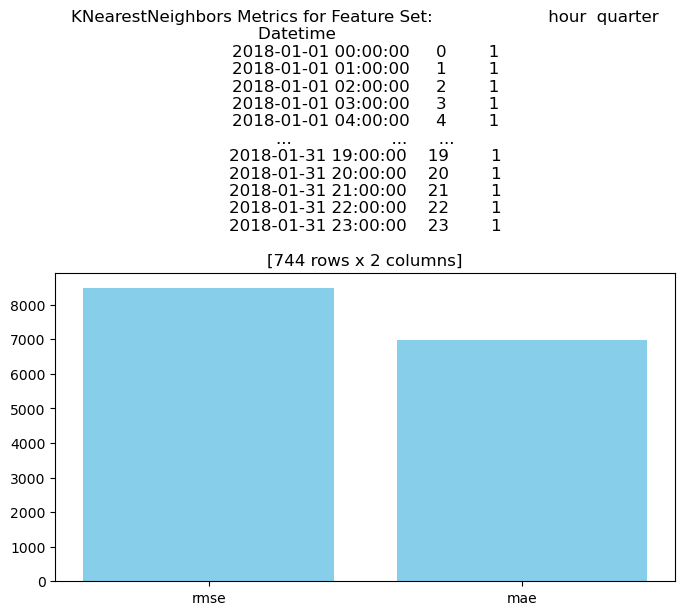

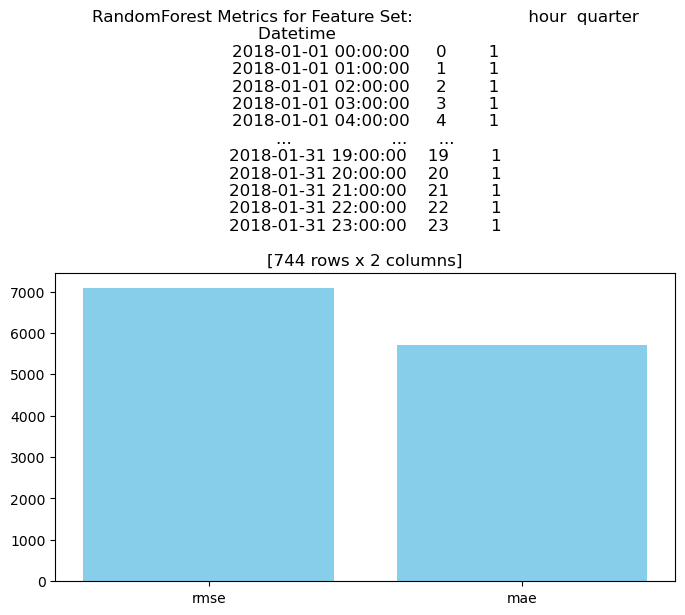

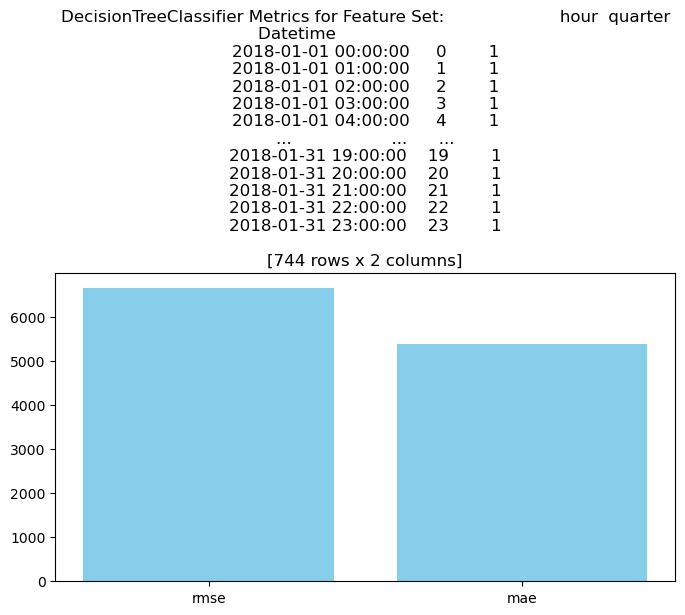

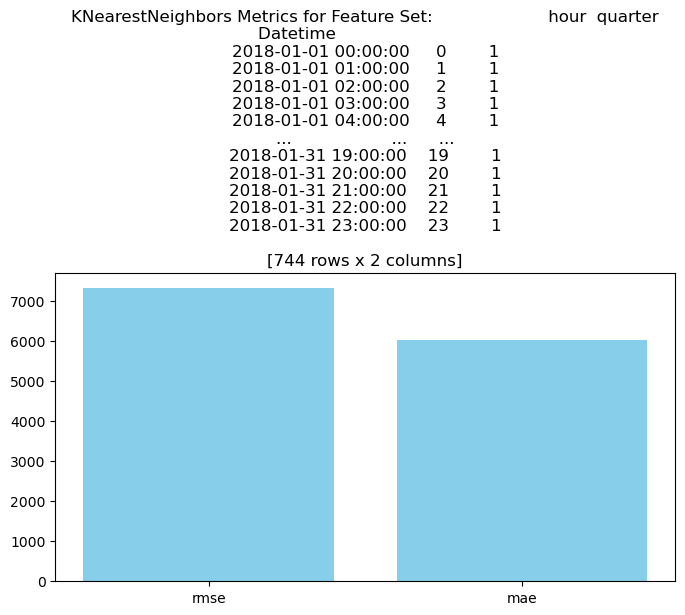

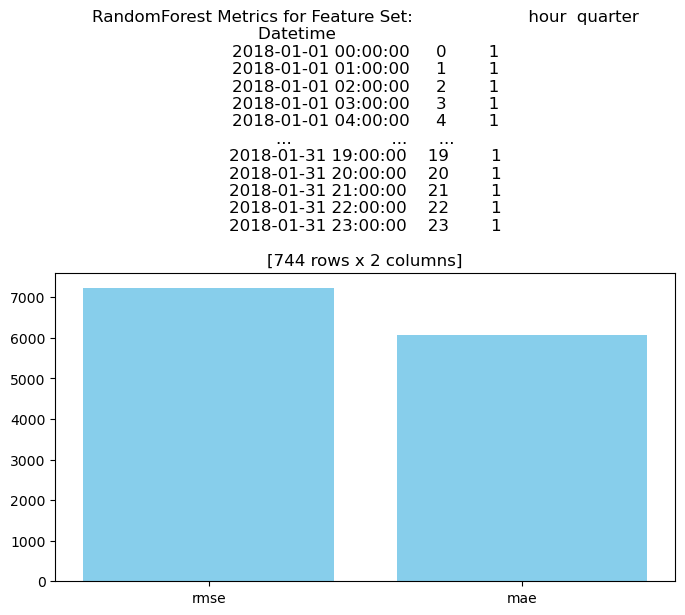

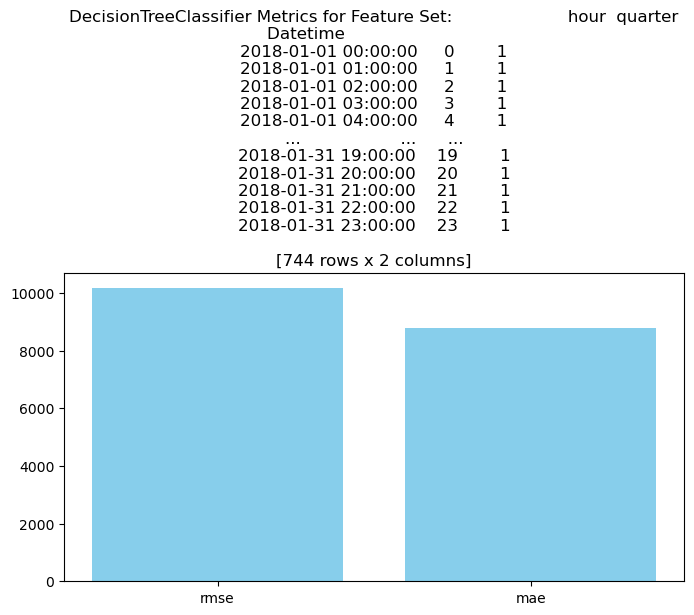

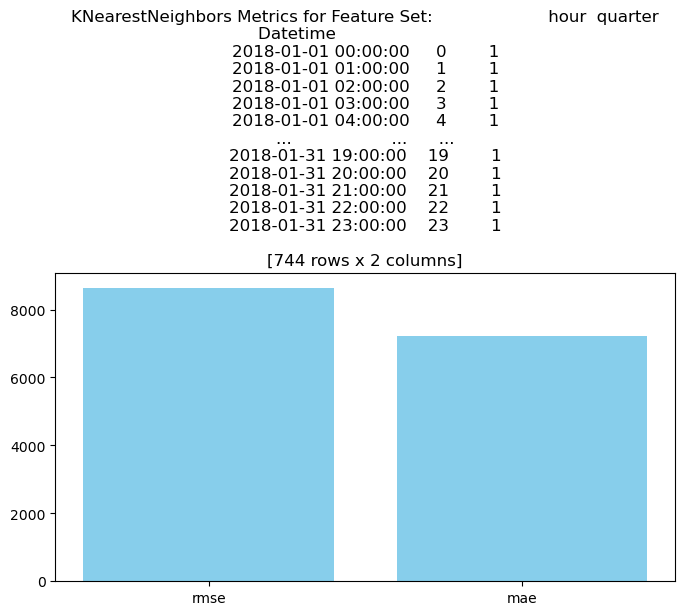

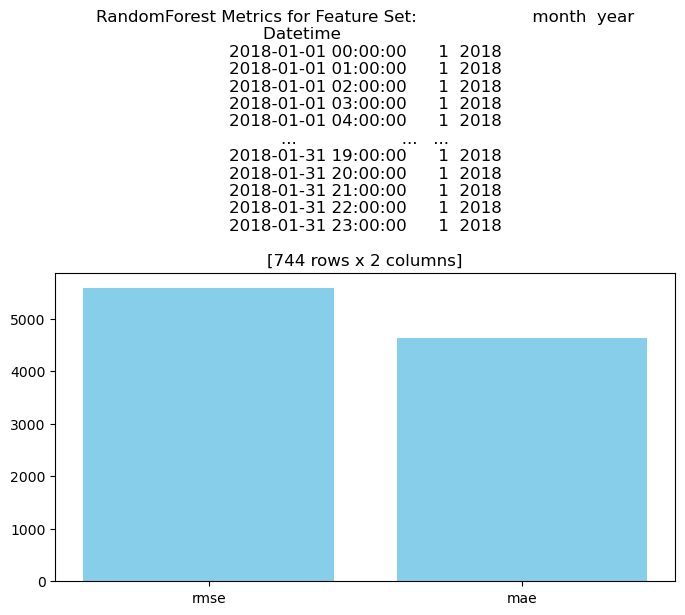

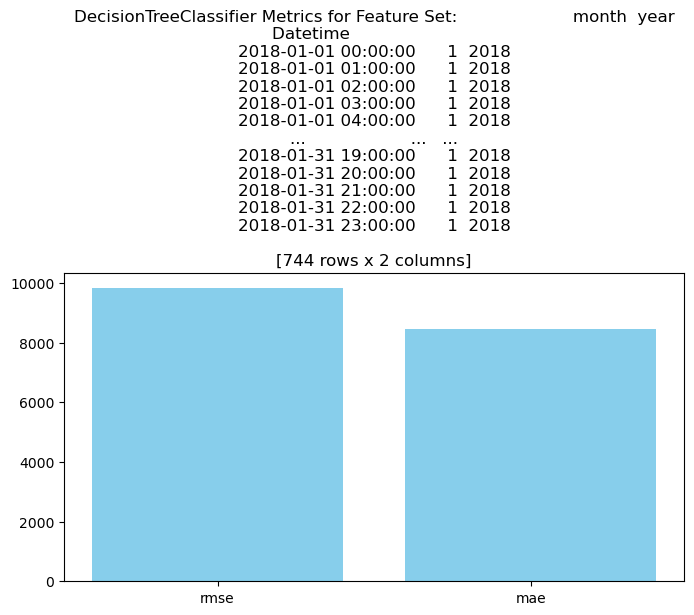

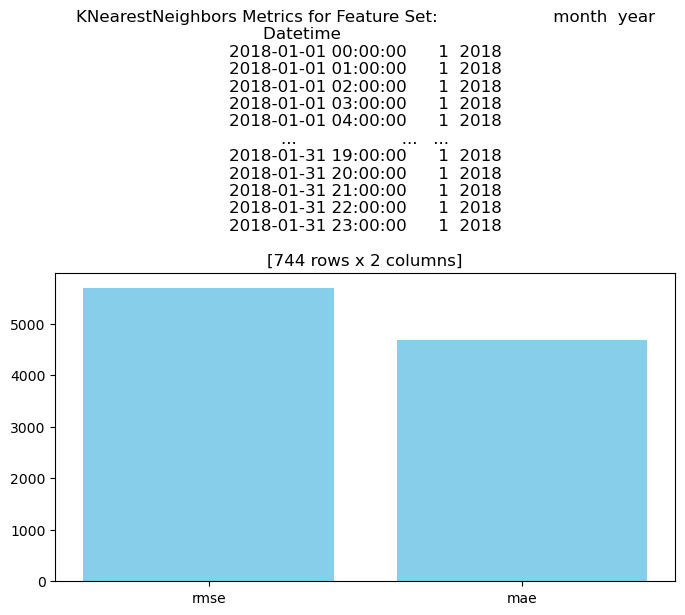

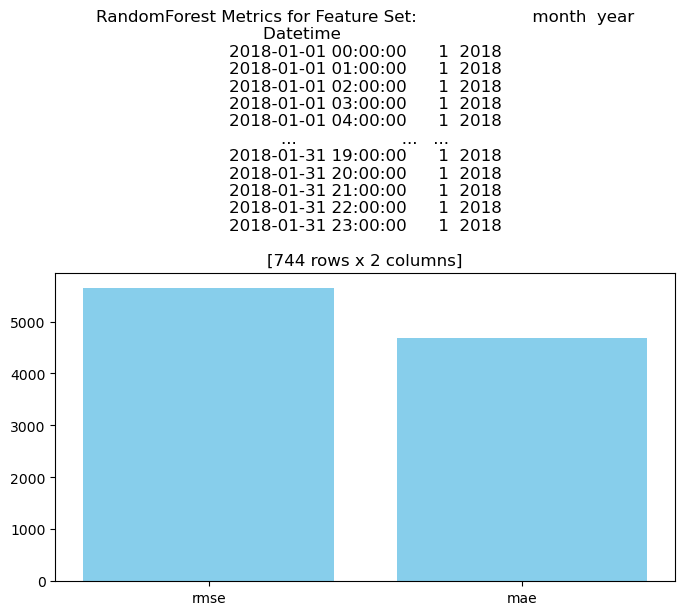

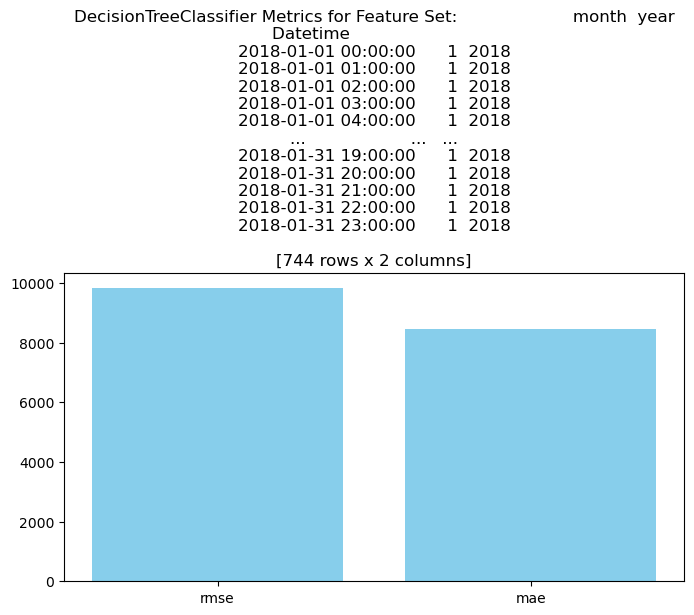

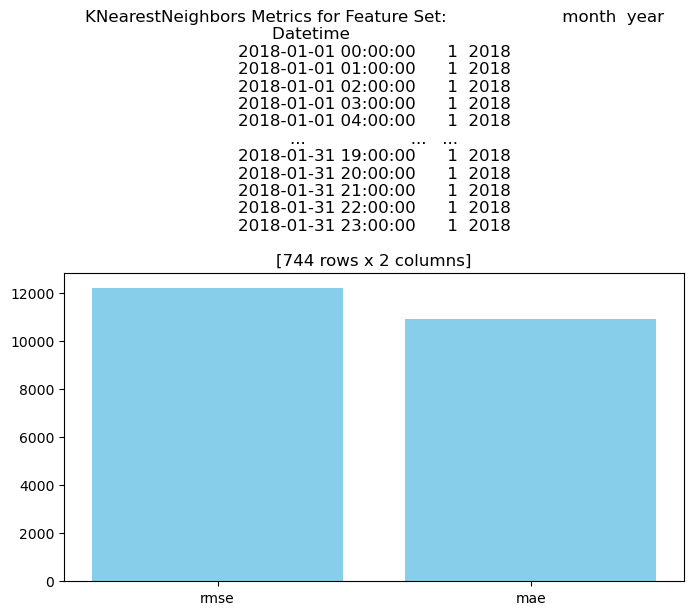

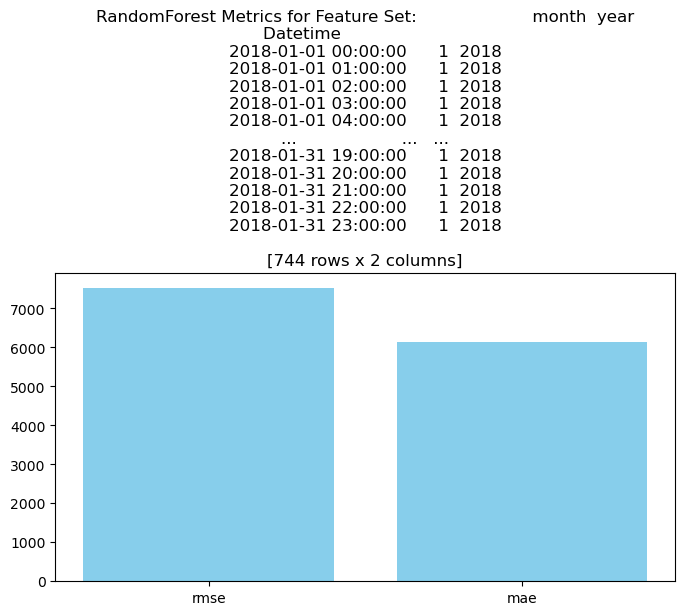

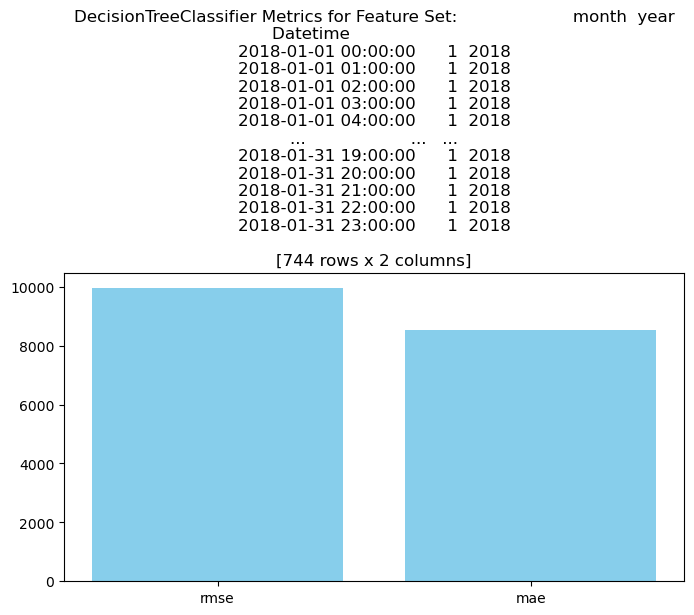

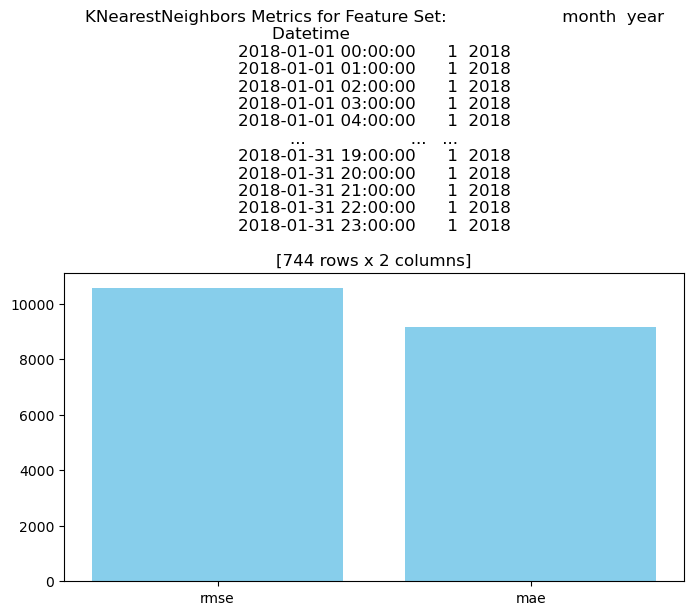

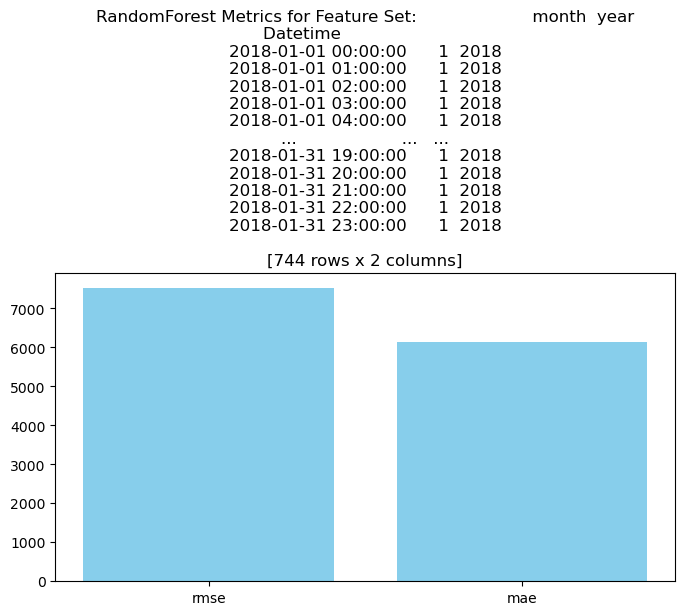

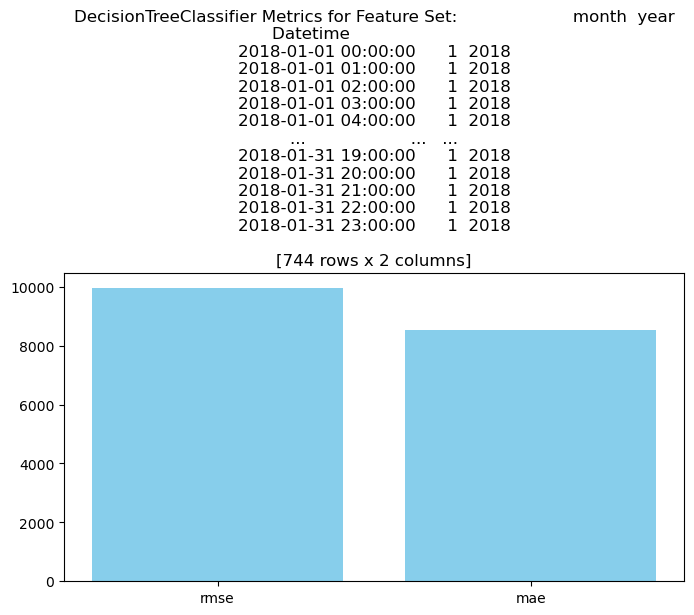

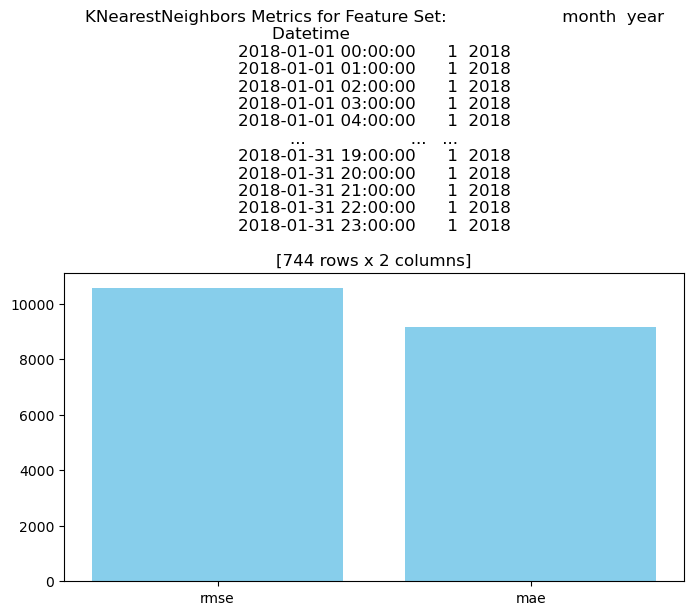

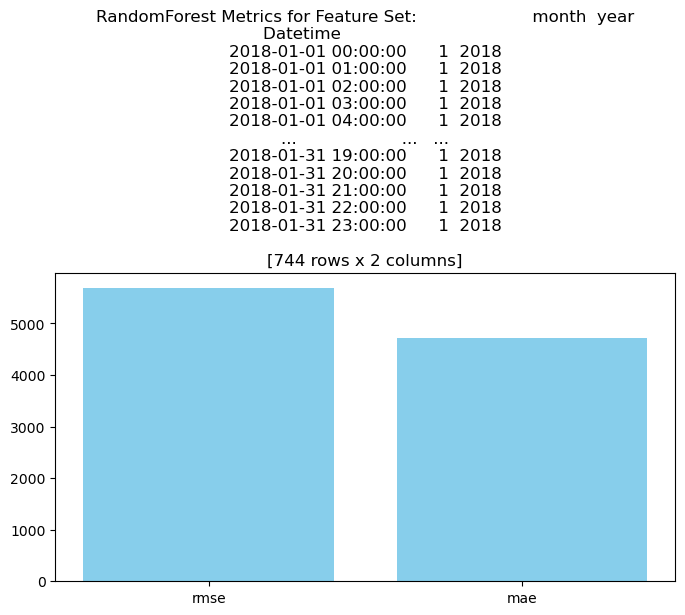

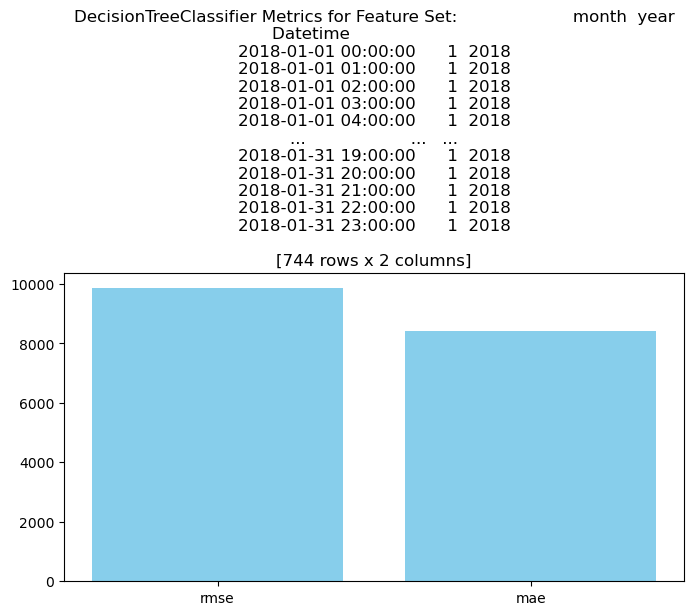

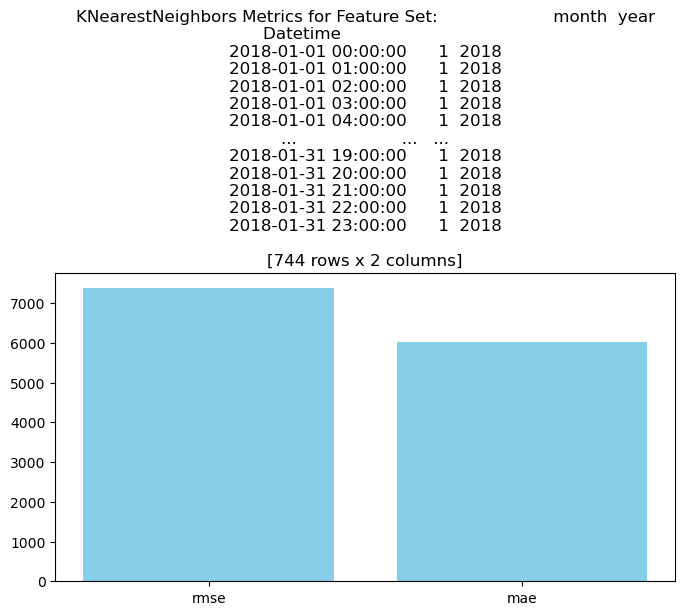

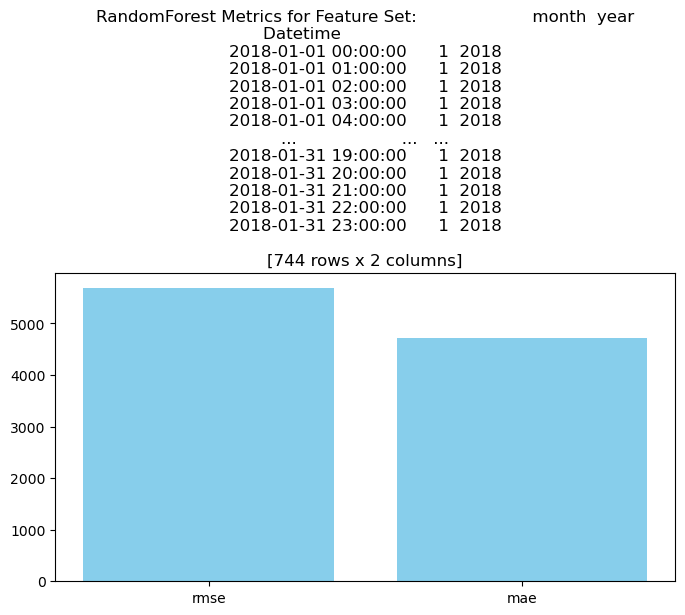

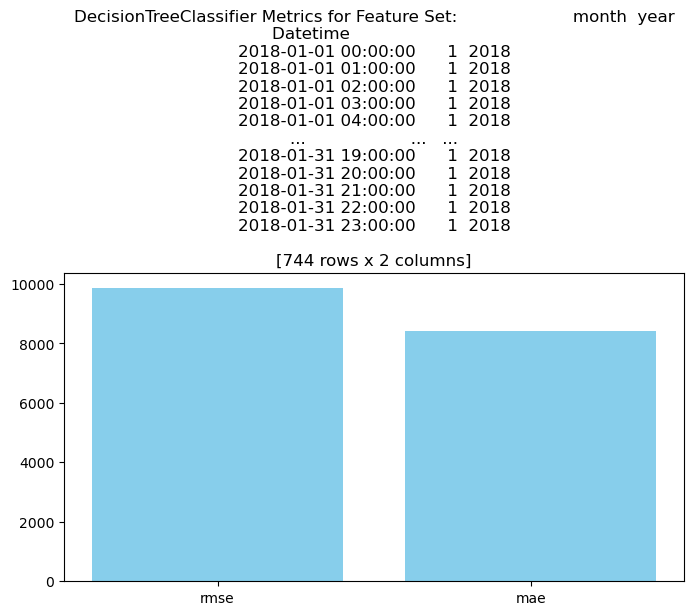

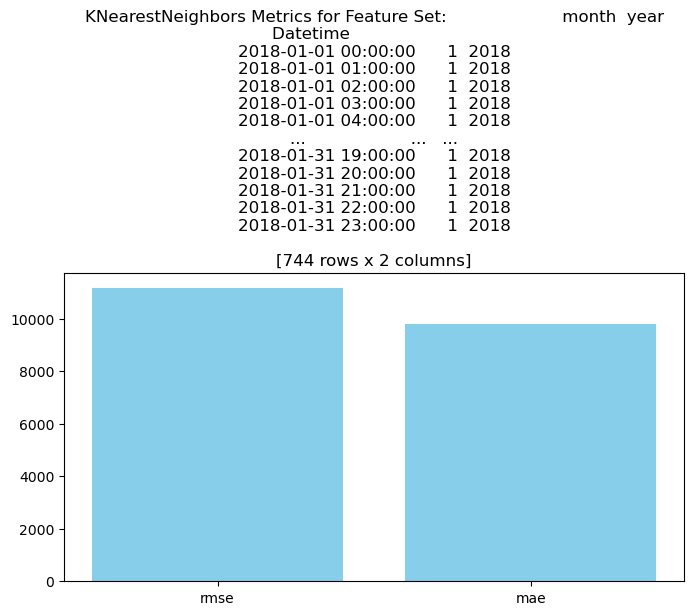

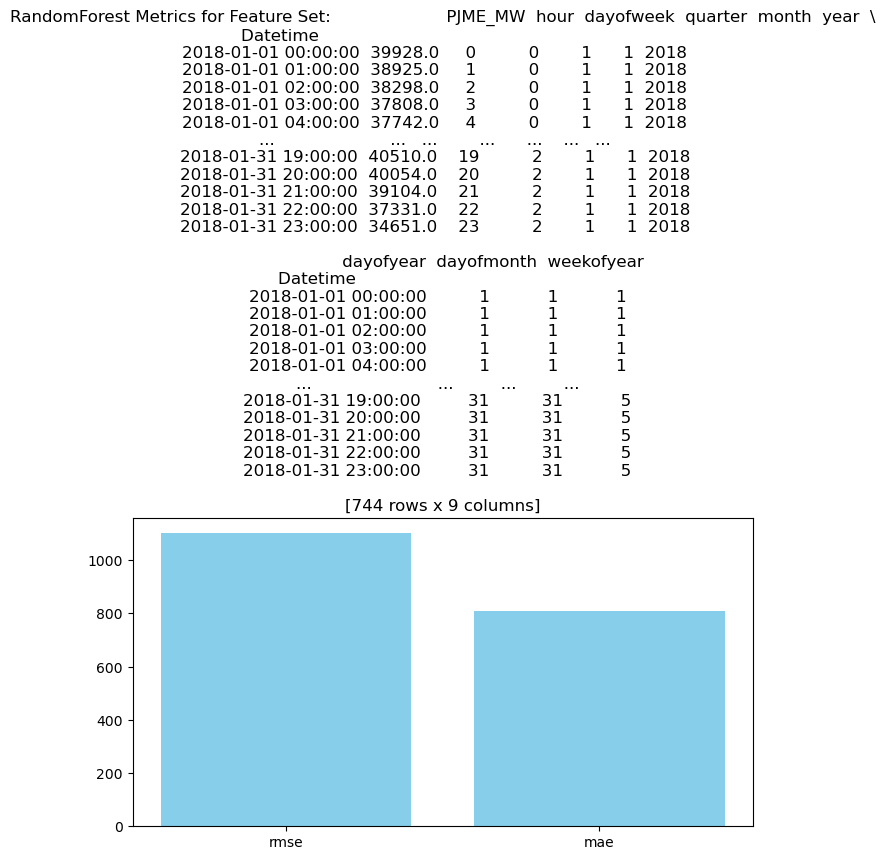

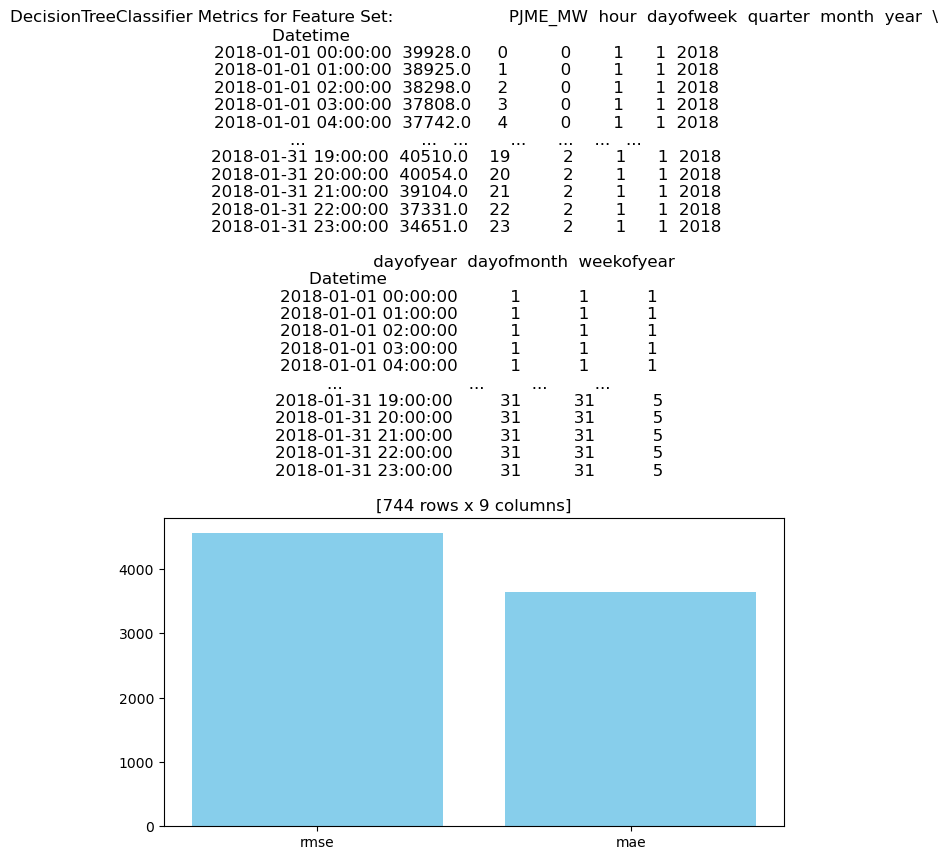

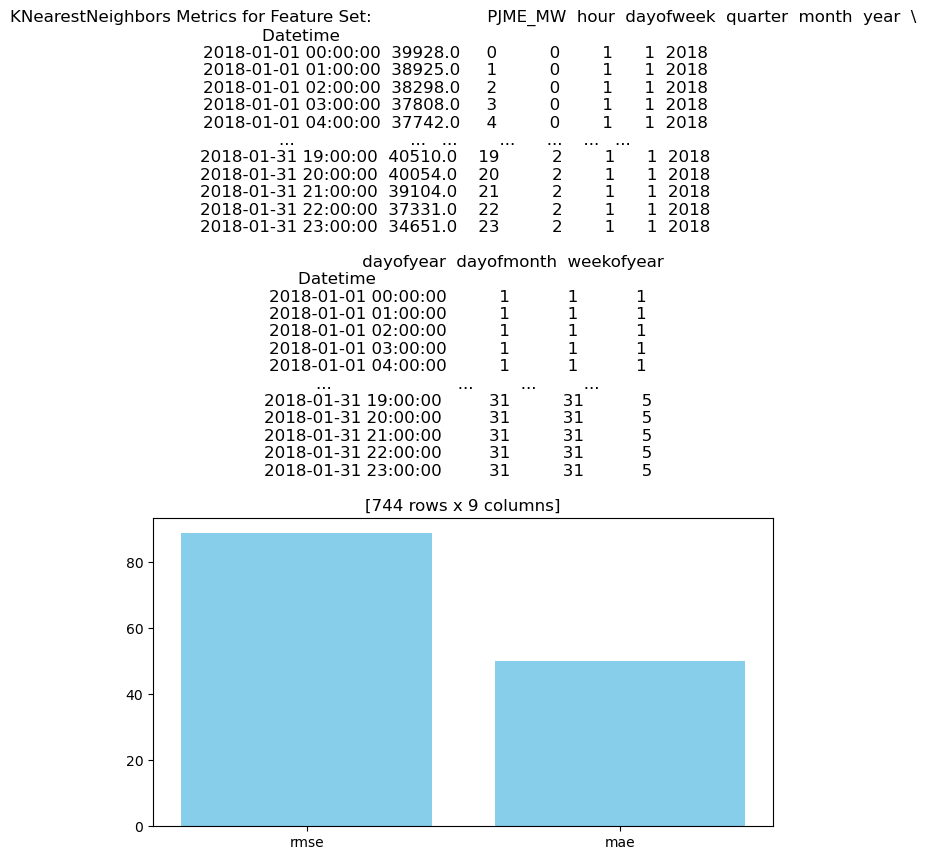

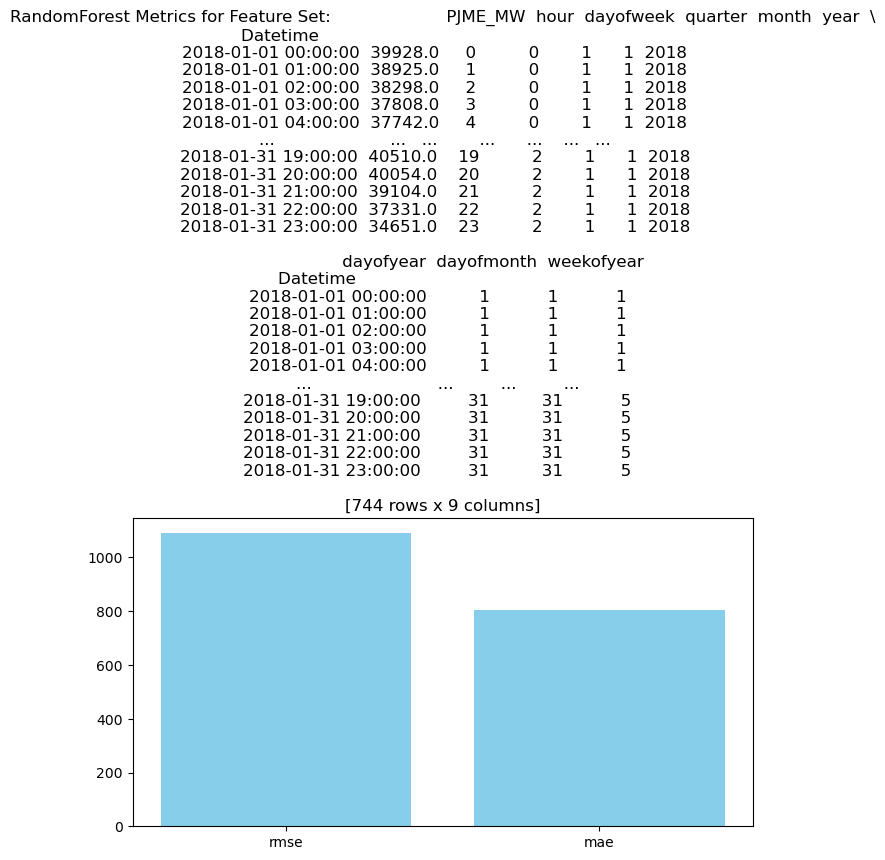

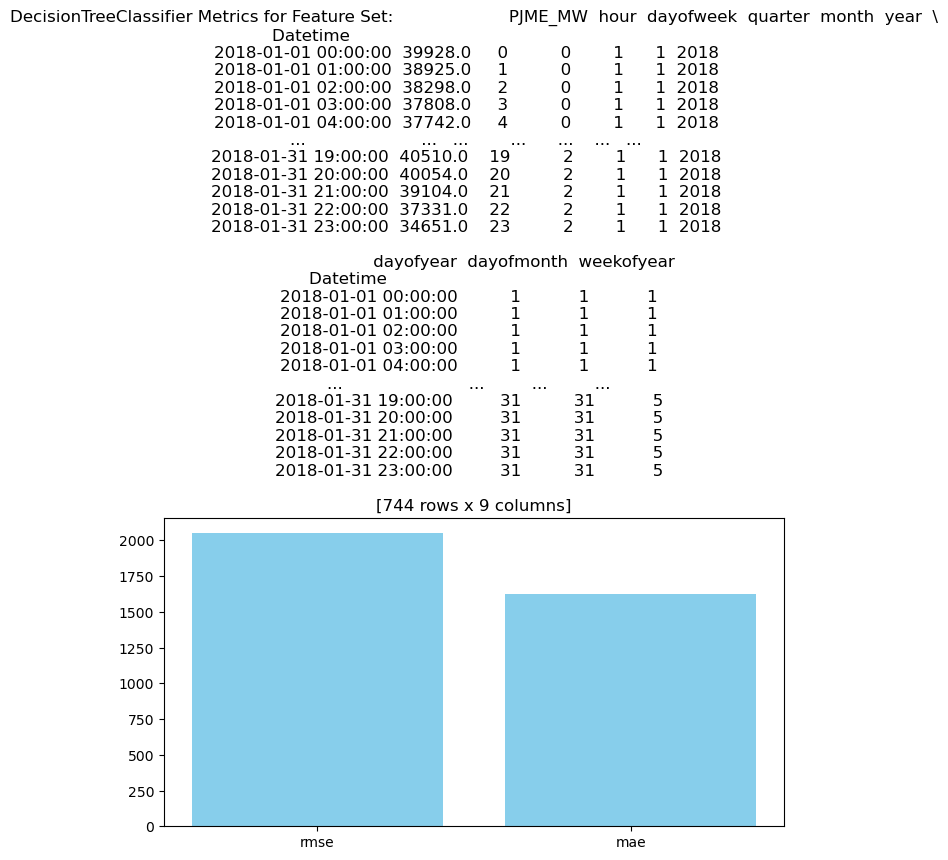

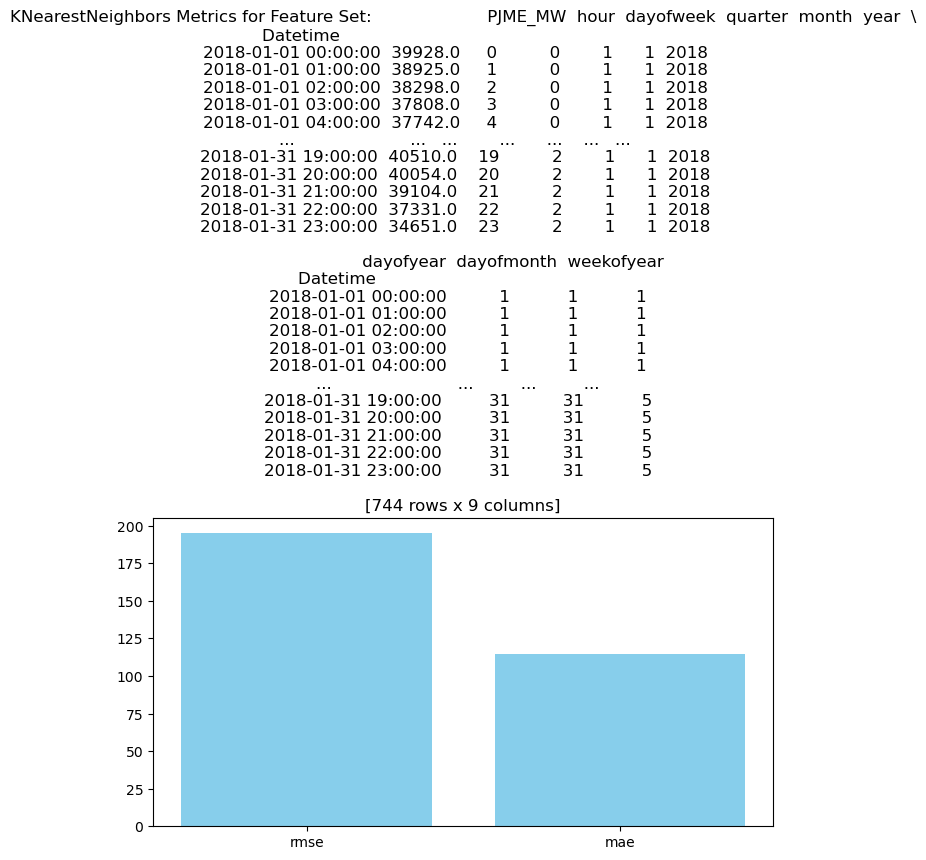

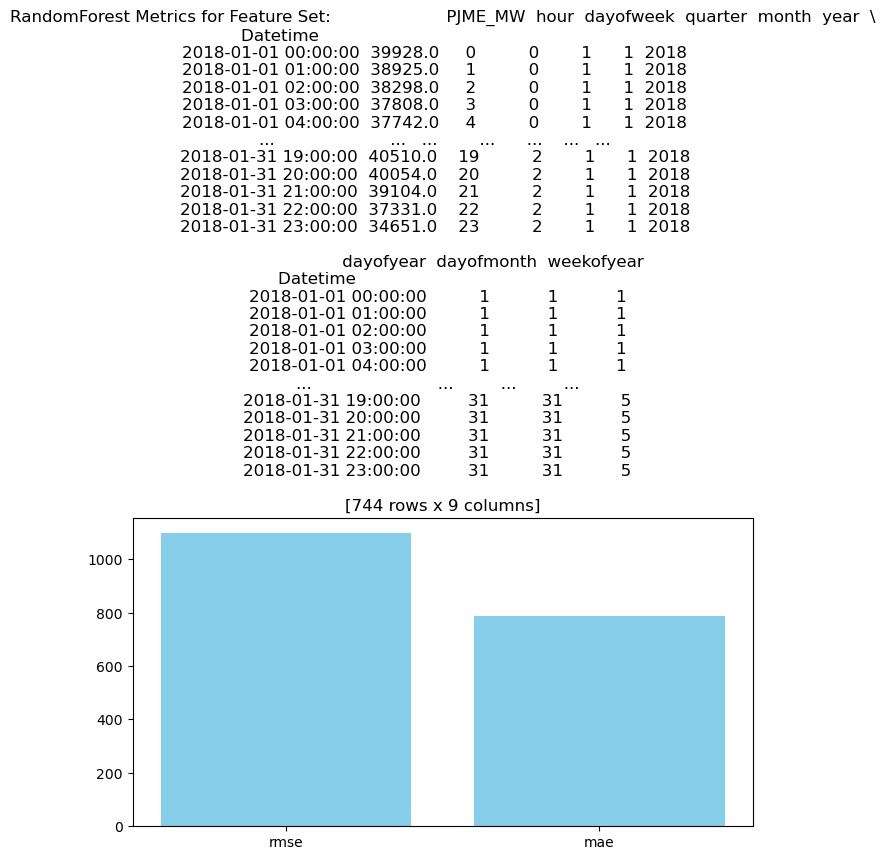

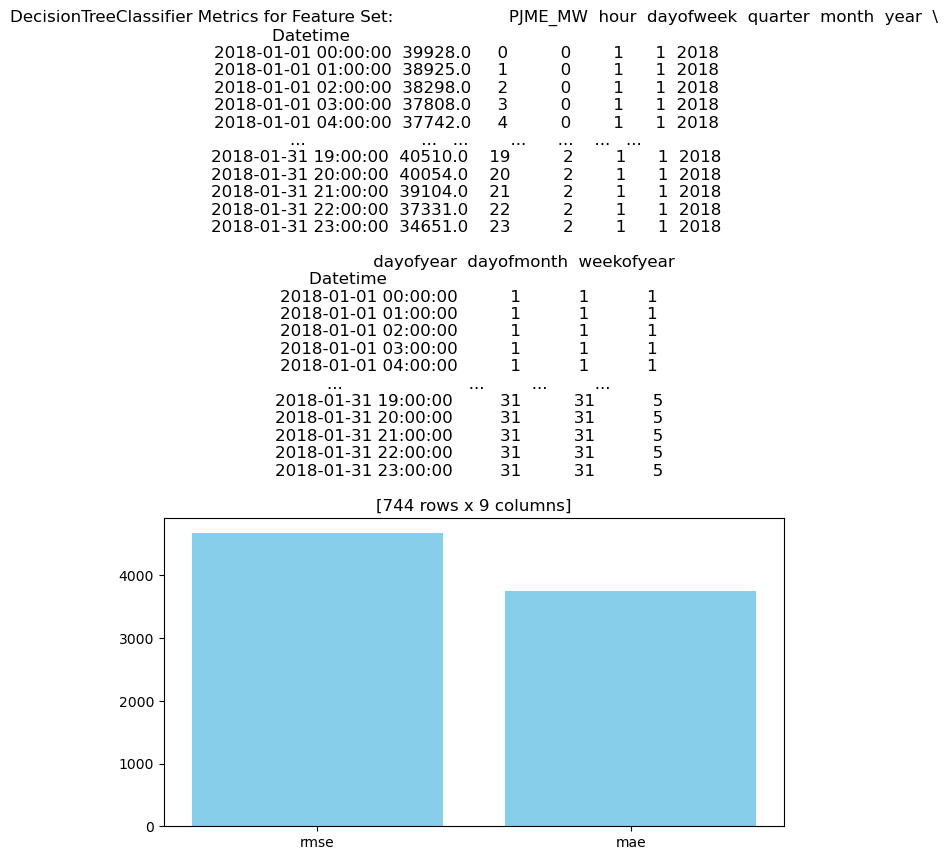

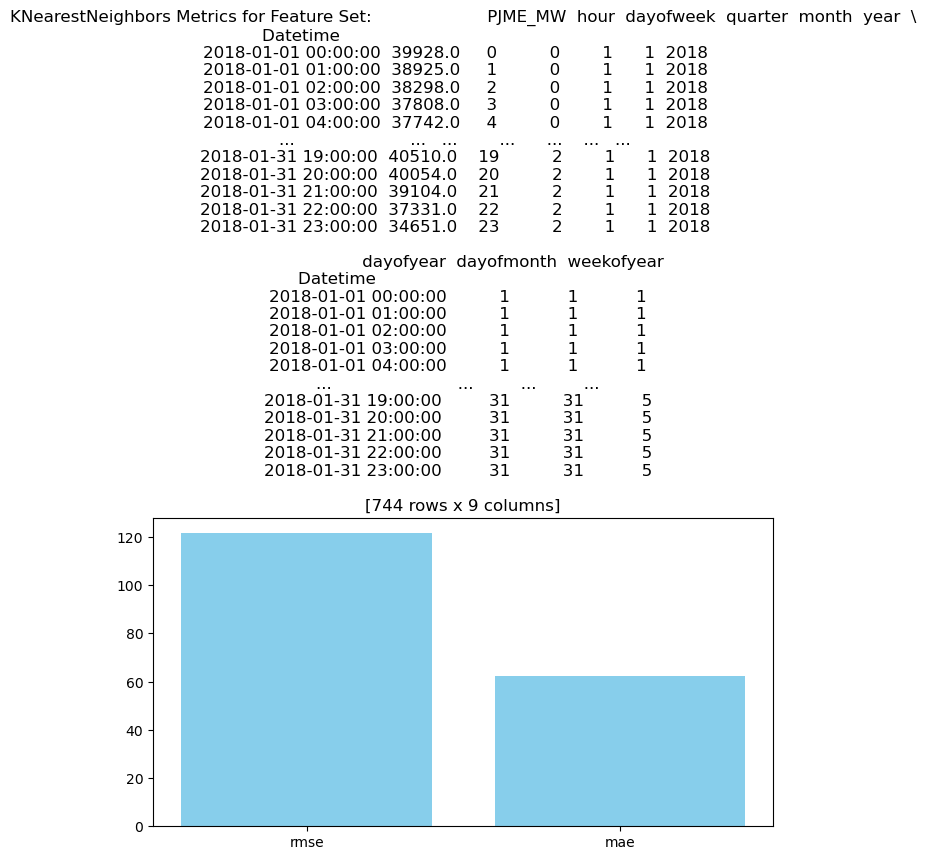

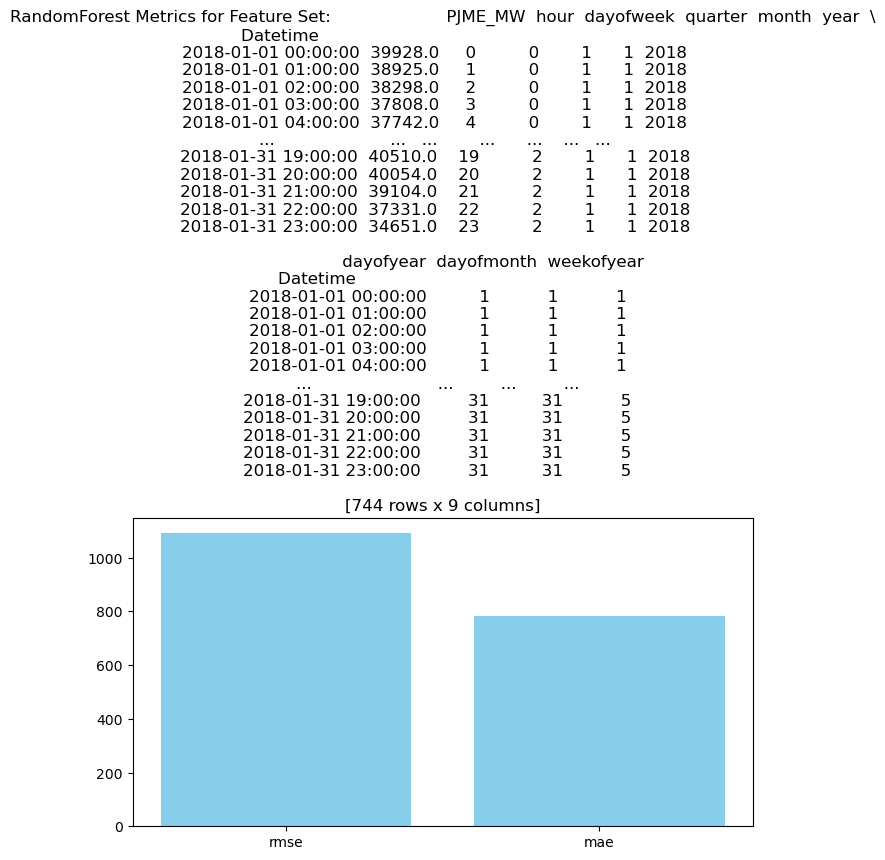

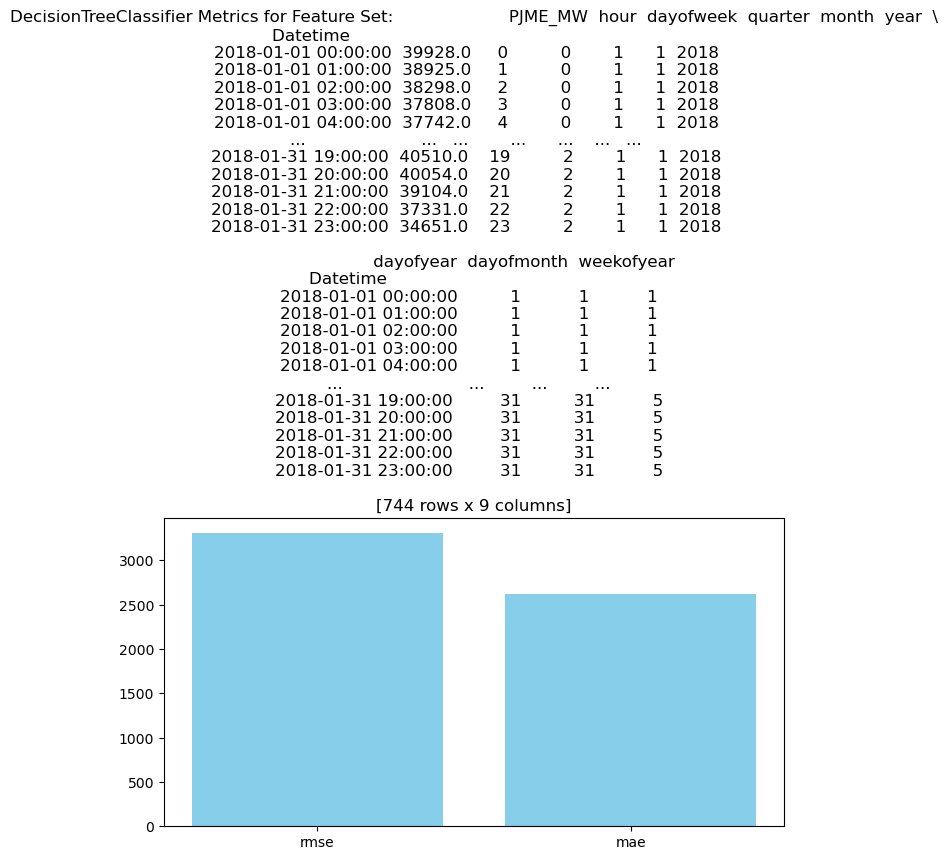

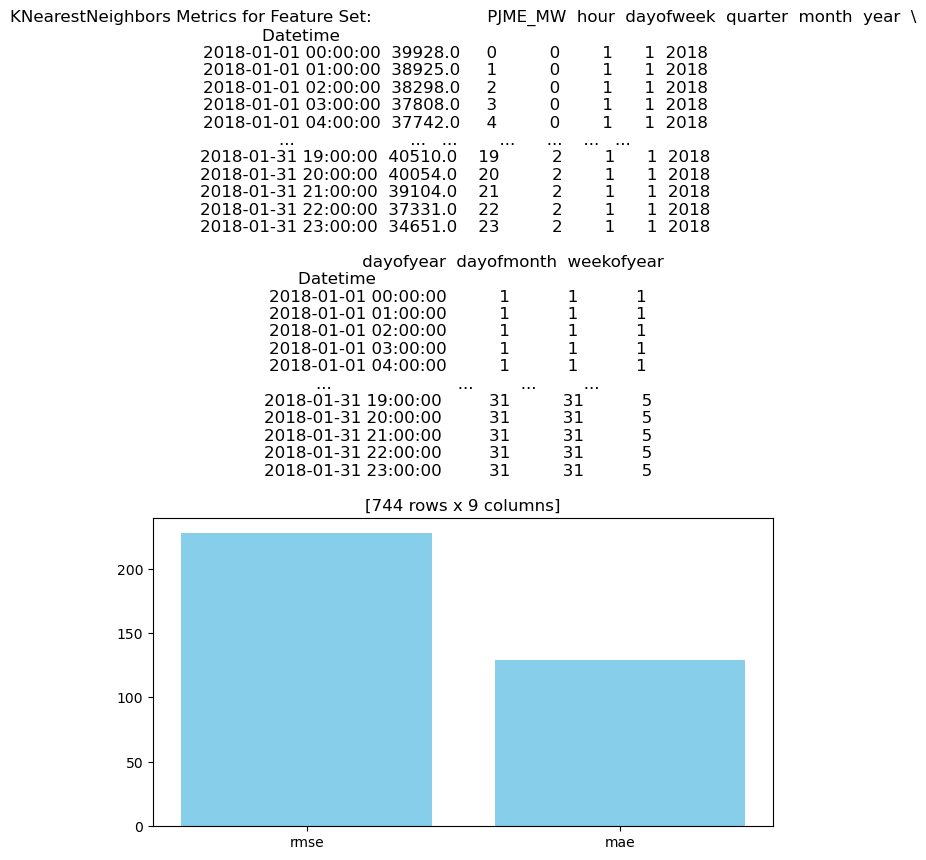

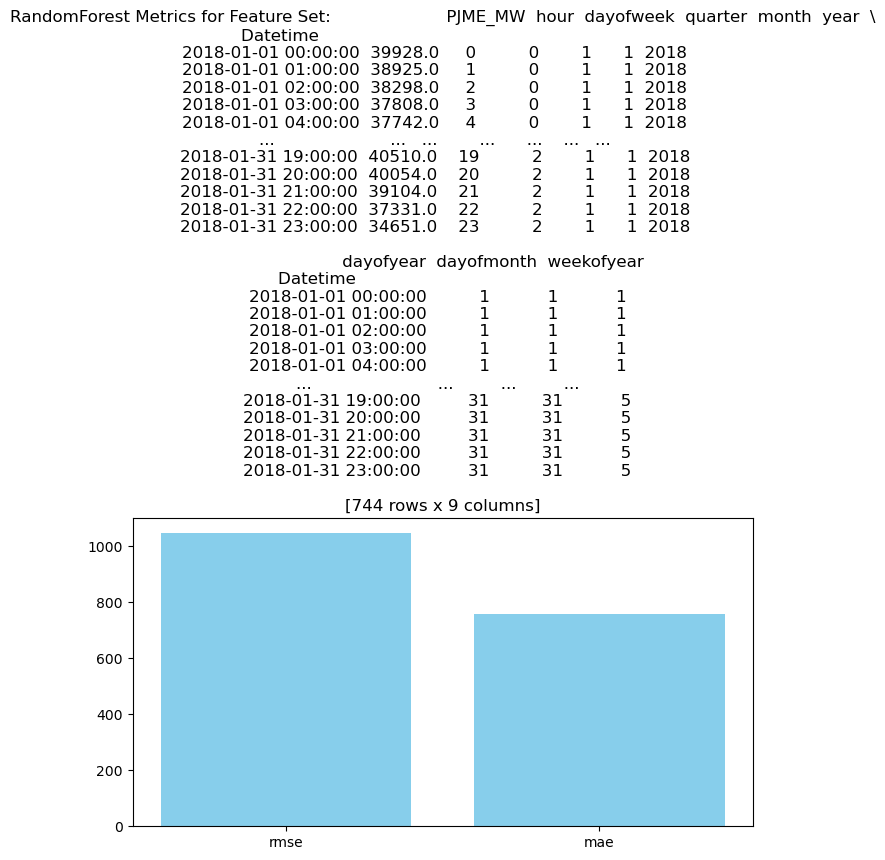

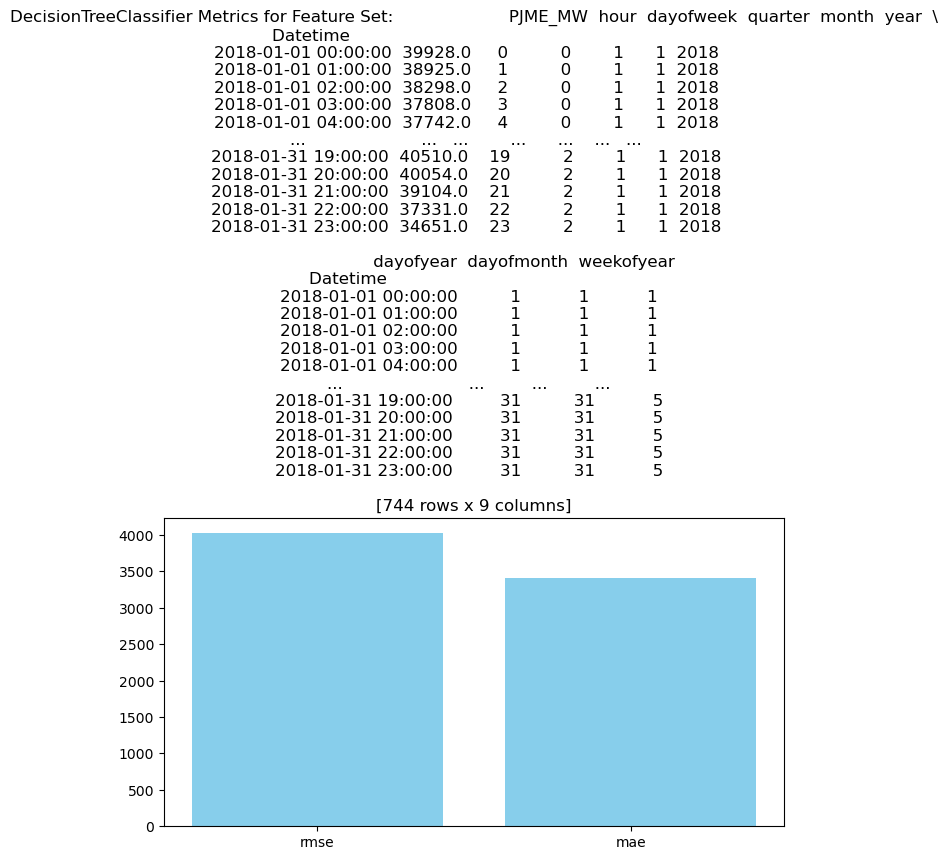

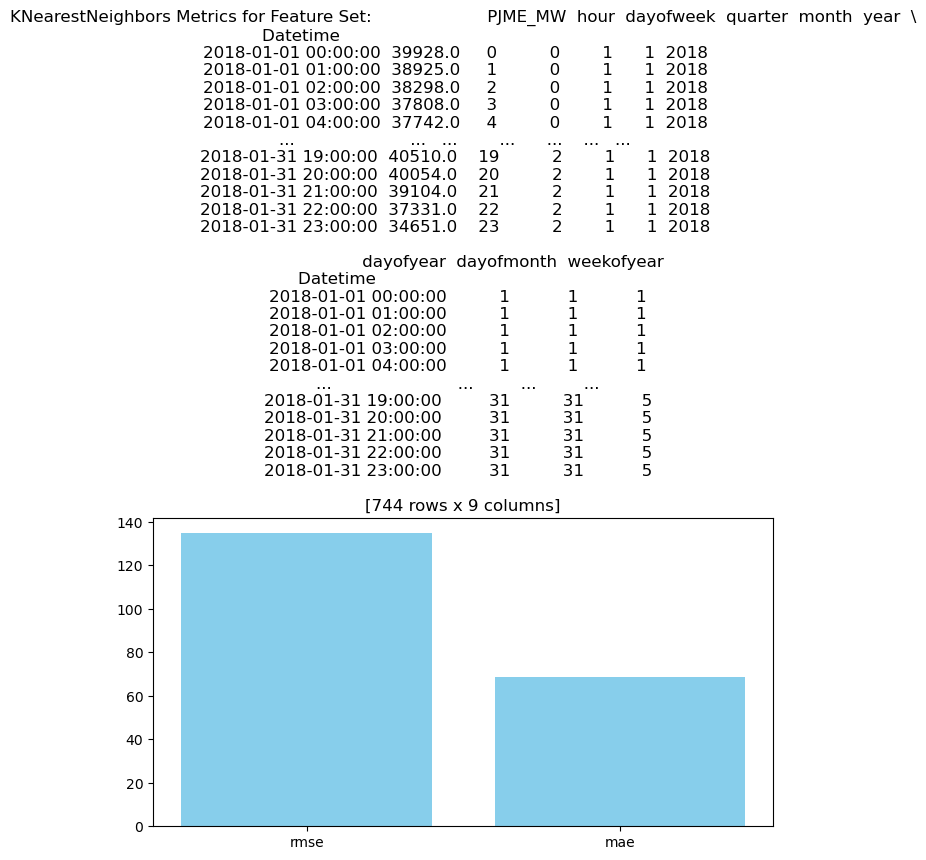

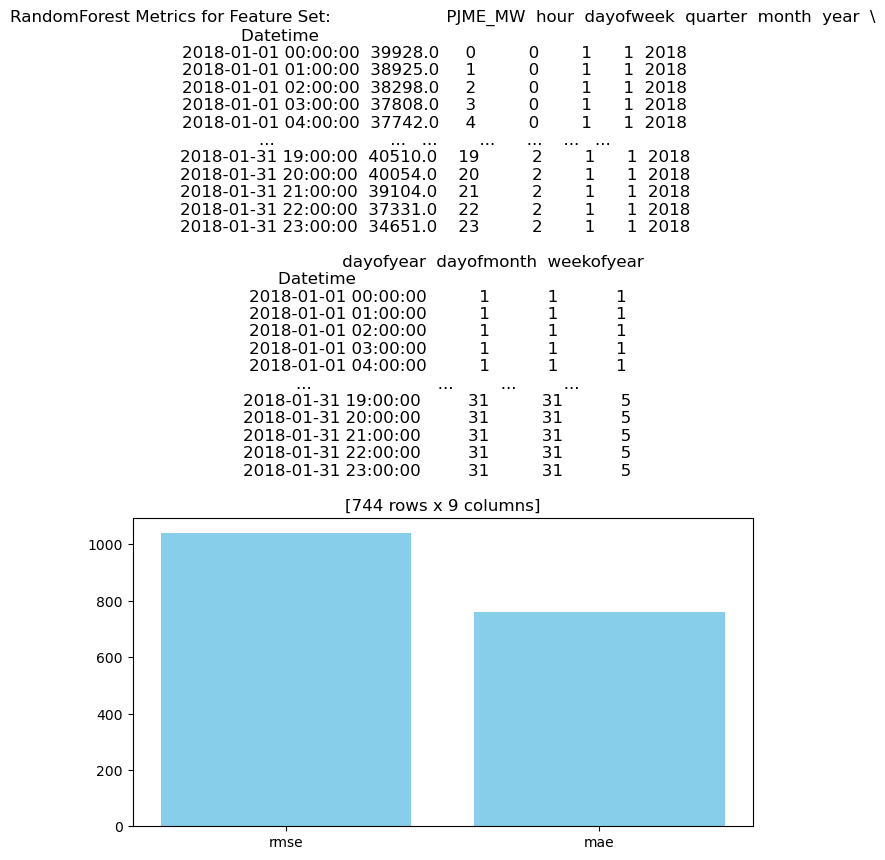

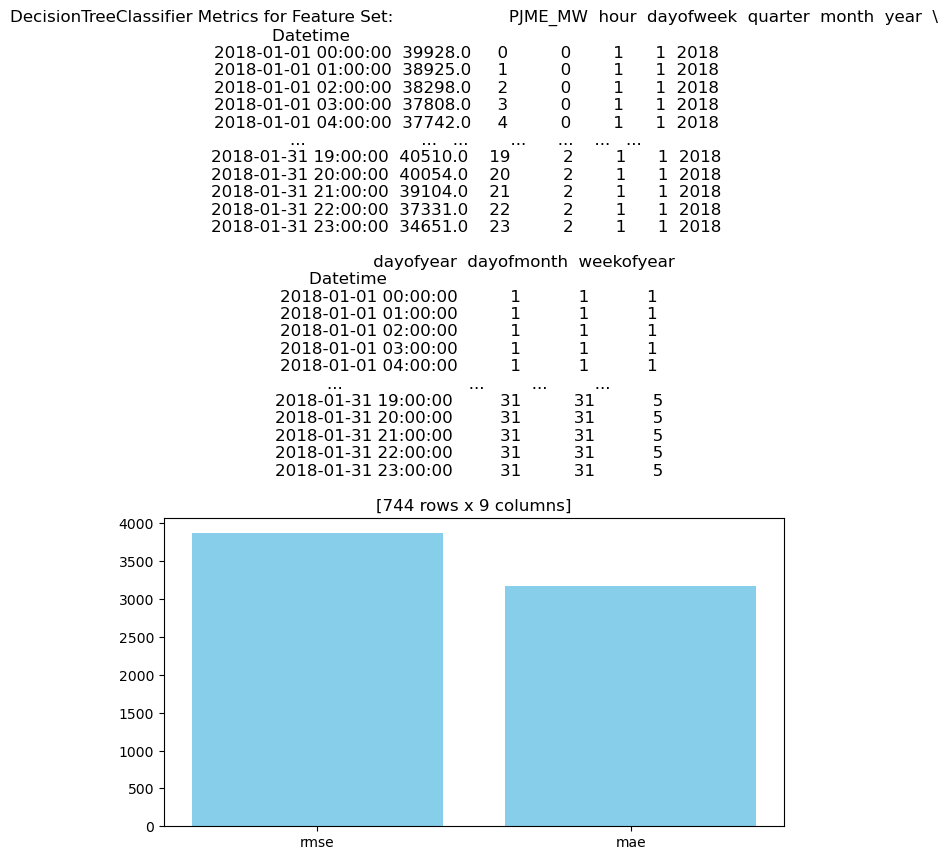

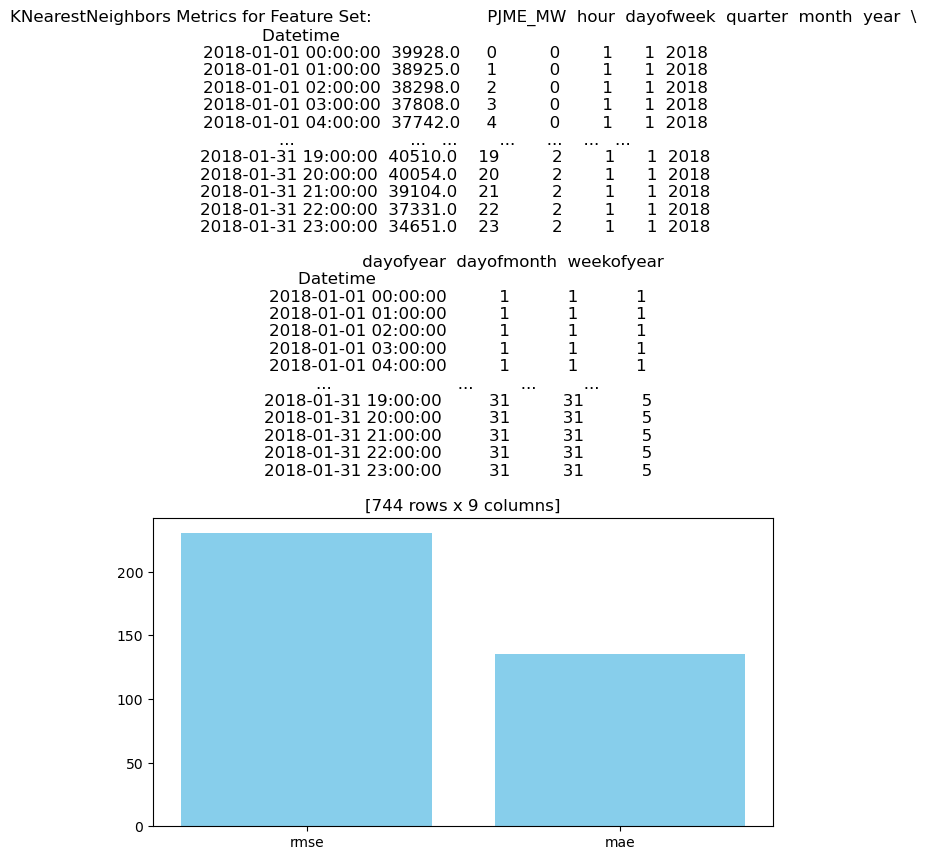

In [16]:

# Start MLFlow experiment
mlflow.set_experiment("MLFlow Experiment Tracking Example")

results = []

# Train models with different feature combinations
for features in feature_combinations:
    # Use different test sample sizes
    for size in t_sizes:
          # This loop is for selecting the hyperparameters in the next loop, where we are using i as the index of the hyperparams array.
          for i in range(0,2): 
            # in this part of the nested loop we set the model.
            for model_name, model in zip(["RandomForest", "DecisionTreeClassifier","KNearestNeighbors"], 
                                         [RandomForestClassifier(n_estimators=hyperparams[0][i],random_state=42),
                                          DecisionTreeClassifier(max_depth=hyperparams[1][i]),
                                          KNeighborsClassifier(n_neighbors=hyperparams[2][i])]):
                with mlflow.start_run():

                    # if statements used to record the hyperparameters
                    param_num = 0
                    param_name = ""
                    
                    if model == "RandomForest":
                        param_num = 0
                        param_name = "n_estimators"
                    elif model == "DecisionTreeClassifier":
                        param_num = 1
                        param_name = "max_depth"
                    else:
                        param_num = 2
                        param_name = "n_neighbors"
                        
                    # Log feature combination and model type
                    mlflow.log_param("features", features)
                    mlflow.log_param("model_type", model_name)
                    mlflow.log_param(param_name,hyperparams[param_num][i])
                    
                    # Train the model
                    X = features
                    print(X.shape, y.shape)
                    X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=size, random_state=12)
                    model.fit(X_train, y_train)
                    predictions = model.predict(X_test)
                    
                    # Calculate metrics
                    rmse = root_mean_squared_error(y_test, predictions)
                    mae = mean_absolute_error(y_test, predictions)
                    
                    # Log metrics
                    mlflow.log_metric("rmse", rmse)
                    mlflow.log_metric("mae", mae)
              
            
                    # Create and log a plot of the metrics
                    fig, ax = plt.subplots(figsize=(8, 4))
                    metrics = [rmse,mae]
                    metric_names = ["rmse", "mae"]
                    ax.bar(metric_names, metrics, color='skyblue')
                    ax.set_title(f"{model_name} Metrics for Feature Set: {features}")
                    #ax.set_ylim(0, 8)
                    
                    # Save the plot to a temporary file and log it as an artifact
                    temp_file = tempfile.NamedTemporaryFile(suffix=".png", delete=False)
                    plt.savefig(temp_file.name)
                    mlflow.log_artifact(temp_file.name, artifact_path="plots")
                    temp_file.close()
                    
                    # Log the model
                    mlflow.sklearn.log_model(model, model_name)
                 
                        
                    # Store results in a dataframe for summary
                    results.append({
                        "features": features,
                        "model": model_name,
                        "test size": size,
                        "hyperparameter": hyperparams[param_num][i], 
                        "rmse" : rmse,
                        "mae" : mae
                    })

# Print summary of results
results_df = pd.DataFrame(results)
print("\nSummary of Experiment Results:")
print(results_df)

In [17]:
# Start MLFlow UI from the notebook
print("\nStarting MLFlow UI...")
process = subprocess.Popen(["mlflow", "ui", "--port", "5000"])  # Starts MLFlow UI on port 5000

# Wait a moment to ensure the server starts
time.sleep(3)

# Display a link to the MLFlow UI
display.display(display.Markdown("[Open MLFlow UI](http://localhost:5000)"))

print("MLFlow UI is running at http://localhost:5000. Press Ctrl+C in the terminal to stop it.")


Starting MLFlow UI...


[Open MLFlow UI](http://localhost:5000)

MLFlow UI is running at http://localhost:5000. Press Ctrl+C in the terminal to stop it.


In [18]:
!mlflow ui

^C


**Here are the results from the loop above:**

In [19]:
results_df


,features,model,test size,hyperparameter,rmse,mae
0,hour quarter Datetime ...,RandomForest,0.20,3,7153.472700,5920.530201
1,hour quarter Datetime ...,DecisionTreeClassifier,0.20,3,7568.714952,6081.825503
2,hour quarter Datetime ...,KNearestNeighbors,0.20,3,6880.624983,5598.416107
3,hour quarter Datetime ...,RandomForest,0.20,6,7127.875231,5735.838926
4,hour quarter Datetime ...,DecisionTreeClassifier,0.20,6,9343.222731,7891.087248
5,hour quarter Datetime ...,KNearestNeighbors,0.20,6,8151.975618,6736.651007
6,hour quarter Datetime ...,RandomForest,0.25,3,7881.686552,6507.327957
7,hour quarter Datetime ...,DecisionTreeClassifier,0.25,3,7035.526791,5559.413978
8,hour quarter Datetime ...,KNearestNeighbors,0.25,3,7715.684658,6294.543011
9,hour quarter Datetime ...,RandomForest,0.25,6,6964.730722,5679.274194


## Conclusion:
**By using mlflow the process of managing the results from a lot of different models get fairly easier by logging each run of the loop with features and metrics, which can be customized to suit the need of the data scientist.**